In [4]:
import pandas as pd
import numpy as np

from pathlib import Path

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Save Model
import joblib

In [6]:
BASE_PATH = Path.cwd().parent

DATASET_PATH = BASE_PATH / "dataset"

PROCESSED_PATH = DATASET_PATH / "processed"

MODELS_PATH = BASE_PATH / "models"
MODELS_PATH.mkdir(exist_ok=True)

In [8]:
csv_path = PROCESSED_PATH / "landmarks.csv"

df = pd.read_csv(csv_path)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [9]:
print("="*50)

print("Shape")
print(df.shape)

print("\nFirst Five Rows")
display(df.head())

print("\nMissing Values")
print(df.isnull().sum().sum())

print("\nClasses")
print(df["label"].nunique())

Shape
(74137, 64)

First Five Rows


,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,...,x18,y18,z18,x19,y19,z19,x20,y20,z20,label
0,0.455066,0.583699,-6.535667e-07,0.569869,0.507308,-0.034267,0.639892,0.374764,-0.041253,0.651905,...,0.391801,0.323449,-0.071389,0.404981,0.408848,-0.056393,0.403411,0.461151,-0.029737,A
1,0.484675,0.614162,-8.084496e-07,0.602145,0.543912,-0.025812,0.676195,0.407449,-0.030664,0.689200,...,0.433379,0.362128,-0.071392,0.446727,0.449884,-0.059598,0.444696,0.504641,-0.038163,A
2,0.562319,0.796830,-6.815258e-07,0.706193,0.709073,-0.047565,0.801895,0.552039,-0.058396,0.821115,...,0.456043,0.469220,-0.094205,0.467616,0.581387,-0.079842,0.475096,0.657608,-0.047797,A
3,0.723497,0.674151,-6.063991e-07,0.796600,0.617823,-0.031191,0.847890,0.513129,-0.036425,0.862495,...,0.623255,0.453557,-0.038356,0.630417,0.509658,-0.031472,0.640656,0.555732,-0.014557,A
4,0.713202,0.752712,-4.978478e-07,0.830028,0.651184,-0.042247,0.897470,0.498115,-0.055674,0.895898,...,0.604023,0.449111,-0.108978,0.632722,0.545297,-0.094283,0.638129,0.612068,-0.063292,A



Missing Values
0

Classes
29


In [10]:
df = df[df["label"] != "nothing"].reset_index(drop=True)

print(df["label"].value_counts())

label
F        2998
J        2912
D        2903
L        2849
H        2844
G        2832
K        2820
U        2774
R        2771
B        2770
S        2765
V        2759
Y        2720
W        2681
Z        2673
I        2668
O        2642
C        2622
A        2617
T        2601
Q        2528
E        2522
space    2489
P        2474
X        2357
del      2287
M        2279
N        1944
Name: count, dtype: int64


In [11]:
print(df.shape)

print()

print(df["label"].nunique())

print()

print(df["label"].value_counts())

(74101, 64)

28

label
F        2998
J        2912
D        2903
L        2849
H        2844
G        2832
K        2820
U        2774
R        2771
B        2770
S        2765
V        2759
Y        2720
W        2681
Z        2673
I        2668
O        2642
C        2622
A        2617
T        2601
Q        2528
E        2522
space    2489
P        2474
X        2357
del      2287
M        2279
N        1944
Name: count, dtype: int64


In [12]:
X = df.drop(columns=["label"])
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst few labels:")
print(y.head())

X shape: (74101, 63)
y shape: (74101,)

First few labels:
0    A
1    A
2    A
3    A
4    A
Name: label, dtype: str


In [13]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Number of classes:", len(label_encoder.classes_))
print("\nClasses:")
print(label_encoder.classes_)

Number of classes: 28

Classes:
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'space']


In [14]:
for number, label in enumerate(label_encoder.classes_):
    print(f"{number:2} -> {label}")

 0 -> A
 1 -> B
 2 -> C
 3 -> D
 4 -> E
 5 -> F
 6 -> G
 7 -> H
 8 -> I
 9 -> J
10 -> K
11 -> L
12 -> M
13 -> N
14 -> O
15 -> P
16 -> Q
17 -> R
18 -> S
19 -> T
20 -> U
21 -> V
22 -> W
23 -> X
24 -> Y
25 -> Z
26 -> del
27 -> space


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining shape:", X_train.shape)
print("Testing shape :", X_test.shape)

Training samples: 59280
Testing samples : 14821

Training shape: (59280, 63)
Testing shape : (14821, 63)


In [16]:
print("Classes in training set:", len(np.unique(y_train)))
print("Classes in testing set :", len(np.unique(y_test)))

Classes in training set: 28
Classes in testing set : 28


In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [18]:
print("Original training data:")
print(X_train.iloc[0, :6].values)

print("\nScaled training data:")
print(X_train_scaled[0, :6])

Original training data:
[ 6.88990593e-01  4.65623349e-01 -3.79232432e-07  6.60254061e-01
  4.82429385e-01 -1.30040318e-01]

Scaled training data:
[ 0.82858425 -1.32028048 -0.78611336  0.30188587 -1.04415502 -1.68583728]


In [21]:
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)

Scaled train shape: (59280, 63)
Scaled test shape : (14821, 63)


In [22]:
import time

start_time = time.time()

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

end_time = time.time()

print("Logistic Regression training completed!")
print(f"Training Time: {end_time - start_time:.2f} seconds")

Logistic Regression training completed!
Training Time: 7.84 seconds


In [23]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions completed!")
print("Number of predictions:", len(y_pred_logistic))

Predictions completed!
Number of predictions: 14821


In [24]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print(
    f"Logistic Regression Accuracy: "
    f"{logistic_accuracy * 100:.2f}%"
)

Logistic Regression Accuracy: 97.14%


In [25]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

           A       0.95      0.96      0.96       523
           B       0.97      1.00      0.99       554
           C       0.97      0.99      0.98       524
           D       0.99      0.98      0.99       581
           E       0.98      0.98      0.98       504
           F       0.98      0.99      0.99       600
           G       0.99      0.99      0.99       566
           H       0.99      0.99      0.99       569
           I       0.98      0.97      0.97       534
           J       0.98      0.97      0.98       583
           K       0.98      0.99      0.99       564
           L       1.00      0.99      0.99       570
           M       0.89      0.90      0.89       456
           N       0.93      0.87      0.90       389
           O       0.98      0.98      0.98       528
           P       0.99      0.96      0.97       495
           Q       0.97      0.98      0.97       506
           R       0.97    

In [26]:
model_results = {}
model_results["Logistic Regression"] = logistic_accuracy
model_results

{'Logistic Regression': 0.971391943863437}

## Model 2 - KNN

In [27]:
from sklearn.neighbors import KNeighborsClassifier
import time

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    n_jobs=-1
)

start_time = time.time()

knn_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time

print("KNN training completed!")
print(f"Training Time: {training_time:.2f} seconds")

KNN training completed!
Training Time: 0.02 seconds


In [28]:
start_time = time.time()

y_pred_knn = knn_model.predict(X_test_scaled)

prediction_time = time.time() - start_time

print("Predictions completed!")
print("Number of predictions:", len(y_pred_knn))
print(f"Prediction Time: {prediction_time:.2f} seconds")

Predictions completed!
Number of predictions: 14821
Prediction Time: 3.12 seconds


In [29]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")

KNN Accuracy: 97.34%


In [30]:
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

           A       0.98      0.97      0.97       523
           B       0.98      1.00      0.99       554
           C       0.98      1.00      0.99       524
           D       1.00      0.98      0.99       581
           E       0.99      0.97      0.98       504
           F       0.99      1.00      0.99       600
           G       0.98      0.99      0.98       566
           H       0.99      0.98      0.98       569
           I       0.99      0.98      0.98       534
           J       0.99      0.98      0.99       583
           K       0.98      0.99      0.98       564
           L       0.99      0.99      0.99       570
           M       0.90      0.93      0.91       456
           N       0.90      0.90      0.90       389
           O       0.97      0.98      0.98       528
           P       0.98      0.98      0.98       495
           Q       0.98      0.98      0.98       506
           R       0.96    

In [31]:
model_results["KNN"] = knn_accuracy

for model, accuracy in model_results.items():
    print(f"{model:<25} {accuracy * 100:.2f}%")

Logistic Regression       97.14%
KNN                       97.34%


## Model 3 - Random forest

In [32]:
from sklearn.ensemble import RandomForestClassifier
import time

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

random_forest_model.fit(X_train, y_train)

rf_training_time = time.time() - start_time

print("Random Forest training completed!")
print(f"Training Time: {rf_training_time:.2f} seconds")

Random Forest training completed!
Training Time: 12.35 seconds


In [33]:
start_time = time.time()

y_pred_rf = random_forest_model.predict(X_test)

rf_prediction_time = time.time() - start_time

print("Predictions completed!")
print("Number of predictions:", len(y_pred_rf))
print(f"Prediction Time: {rf_prediction_time:.2f} seconds")

Predictions completed!
Number of predictions: 14821
Prediction Time: 0.26 seconds


In [34]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Accuracy: 97.99%


In [35]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

           A       0.99      0.98      0.98       523
           B       0.98      0.99      0.99       554
           C       0.98      1.00      0.99       524
           D       0.99      0.98      0.98       581
           E       0.97      0.98      0.98       504
           F       0.99      0.99      0.99       600
           G       0.99      0.99      0.99       566
           H       0.99      0.99      0.99       569
           I       0.99      0.98      0.99       534
           J       0.99      0.98      0.99       583
           K       0.99      0.99      0.99       564
           L       0.99      0.99      0.99       570
           M       0.93      0.95      0.94       456
           N       0.95      0.91      0.93       389
           O       0.98      0.99      0.98       528
           P       0.99      0.97      0.98       495
           Q       0.98      0.98      0.98       506
           R       0.98    

In [37]:
model_results["Random Forest"] = rf_accuracy

print("MODEL COMPARISON")
print("=" * 40)

for model, accuracy in model_results.items():
    print(f"{model:<25} {accuracy * 100:.2f}%")

MODEL COMPARISON
Logistic Regression       97.14%
KNN                       97.34%
Random Forest             97.99%


#### MODEL 4 - SVM

In [38]:
from sklearn.svm import SVC
import time

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

start_time = time.time()

svm_model.fit(X_train_scaled, y_train)

svm_training_time = time.time() - start_time

print("SVM training completed!")
print(f"Training Time: {svm_training_time:.2f} seconds")

SVM training completed!
Training Time: 20.29 seconds


In [39]:
start_time = time.time()

y_pred_svm = svm_model.predict(X_test_scaled)

svm_prediction_time = time.time() - start_time

print("Predictions completed!")
print("Number of predictions:", len(y_pred_svm))
print(f"Prediction Time: {svm_prediction_time:.2f} seconds")

Predictions completed!
Number of predictions: 14821
Prediction Time: 18.80 seconds


In [40]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print(f"SVM Accuracy: {svm_accuracy * 100:.2f}%")

SVM Accuracy: 98.88%


In [41]:
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

           A       0.97      0.97      0.97       523
           B       0.99      0.99      0.99       554
           C       1.00      1.00      1.00       524
           D       1.00      0.99      0.99       581
           E       0.99      0.99      0.99       504
           F       1.00      0.99      1.00       600
           G       1.00      1.00      1.00       566
           H       0.99      0.99      0.99       569
           I       0.99      0.99      0.99       534
           J       0.99      0.99      0.99       583
           K       1.00      1.00      1.00       564
           L       1.00      0.99      1.00       570
           M       0.96      0.97      0.97       456
           N       0.96      0.95      0.95       389
           O       0.99      1.00      0.99       528
           P       1.00      0.99      0.99       495
           Q       0.99      1.00      0.99       506
           R       0.98    

In [42]:
model_results["SVM"] = svm_accuracy

print("MODEL LEADERBOARD")
print("=" * 45)

for model, accuracy in sorted(
    model_results.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{model:<25} {accuracy * 100:.2f}%")

MODEL LEADERBOARD
SVM                       98.88%
Random Forest             97.99%
KNN                       97.34%
Logistic Regression       97.14%


### Model 5 - MLP Neural Network

In [43]:
from sklearn.neural_network import MLPClassifier
import time

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=True
)

start_time = time.time()

mlp_model.fit(X_train_scaled, y_train)

mlp_training_time = time.time() - start_time

print("\nMLP training completed!")
print(f"Training Time: {mlp_training_time:.2f} seconds")
print(f"Epochs completed: {mlp_model.n_iter_}")

Iteration 1, loss = 1.05910218
Validation score: 0.928981
Iteration 2, loss = 0.23143164
Validation score: 0.957152
Iteration 3, loss = 0.16083673
Validation score: 0.965081
Iteration 4, loss = 0.13274575
Validation score: 0.964575
Iteration 5, loss = 0.11504111
Validation score: 0.972841
Iteration 6, loss = 0.10279655
Validation score: 0.972503
Iteration 7, loss = 0.09525457
Validation score: 0.971829
Iteration 8, loss = 0.08593992
Validation score: 0.976046
Iteration 9, loss = 0.08015243
Validation score: 0.973516
Iteration 10, loss = 0.07708725
Validation score: 0.976552
Iteration 11, loss = 0.07173700
Validation score: 0.979588
Iteration 12, loss = 0.06607869
Validation score: 0.980094
Iteration 13, loss = 0.06459487
Validation score: 0.980938
Iteration 14, loss = 0.06148944
Validation score: 0.979251
Iteration 15, loss = 0.05842411
Validation score: 0.980432
Iteration 16, loss = 0.05476796
Validation score: 0.982625
Iteration 17, loss = 0.05204709
Validation score: 0.980769
Iterat

In [44]:
start_time = time.time()

y_pred_mlp = mlp_model.predict(X_test_scaled)

mlp_prediction_time = time.time() - start_time

print("Predictions completed!")
print("Number of predictions:", len(y_pred_mlp))
print(f"Prediction Time: {mlp_prediction_time:.2f} seconds")

Predictions completed!
Number of predictions: 14821
Prediction Time: 0.04 seconds


In [45]:
mlp_accuracy = accuracy_score(
    y_test,
    y_pred_mlp
)

print(f"MLP Accuracy: {mlp_accuracy * 100:.2f}%")

MLP Accuracy: 98.70%


In [46]:
print(
    classification_report(
        y_test,
        y_pred_mlp,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

           A       0.98      0.97      0.98       523
           B       0.99      1.00      0.99       554
           C       1.00      1.00      1.00       524
           D       1.00      0.99      0.99       581
           E       0.99      0.99      0.99       504
           F       0.99      1.00      1.00       600
           G       1.00      0.99      1.00       566
           H       0.99      0.99      0.99       569
           I       0.99      0.99      0.99       534
           J       0.99      0.99      0.99       583
           K       0.99      1.00      0.99       564
           L       1.00      0.99      1.00       570
           M       0.97      0.96      0.96       456
           N       0.95      0.93      0.94       389
           O       0.99      0.99      0.99       528
           P       0.98      0.99      0.99       495
           Q       0.99      0.99      0.99       506
           R       0.99    

In [47]:
model_results["MLP"] = mlp_accuracy

print("FINAL MODEL LEADERBOARD")
print("=" * 45)

for model, accuracy in sorted(
    model_results.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{model:<25} {accuracy * 100:.2f}%")

FINAL MODEL LEADERBOARD
SVM                       98.88%
MLP                       98.70%
Random Forest             97.99%
KNN                       97.34%
Logistic Regression       97.14%


### choosing model (Final Evaluation)

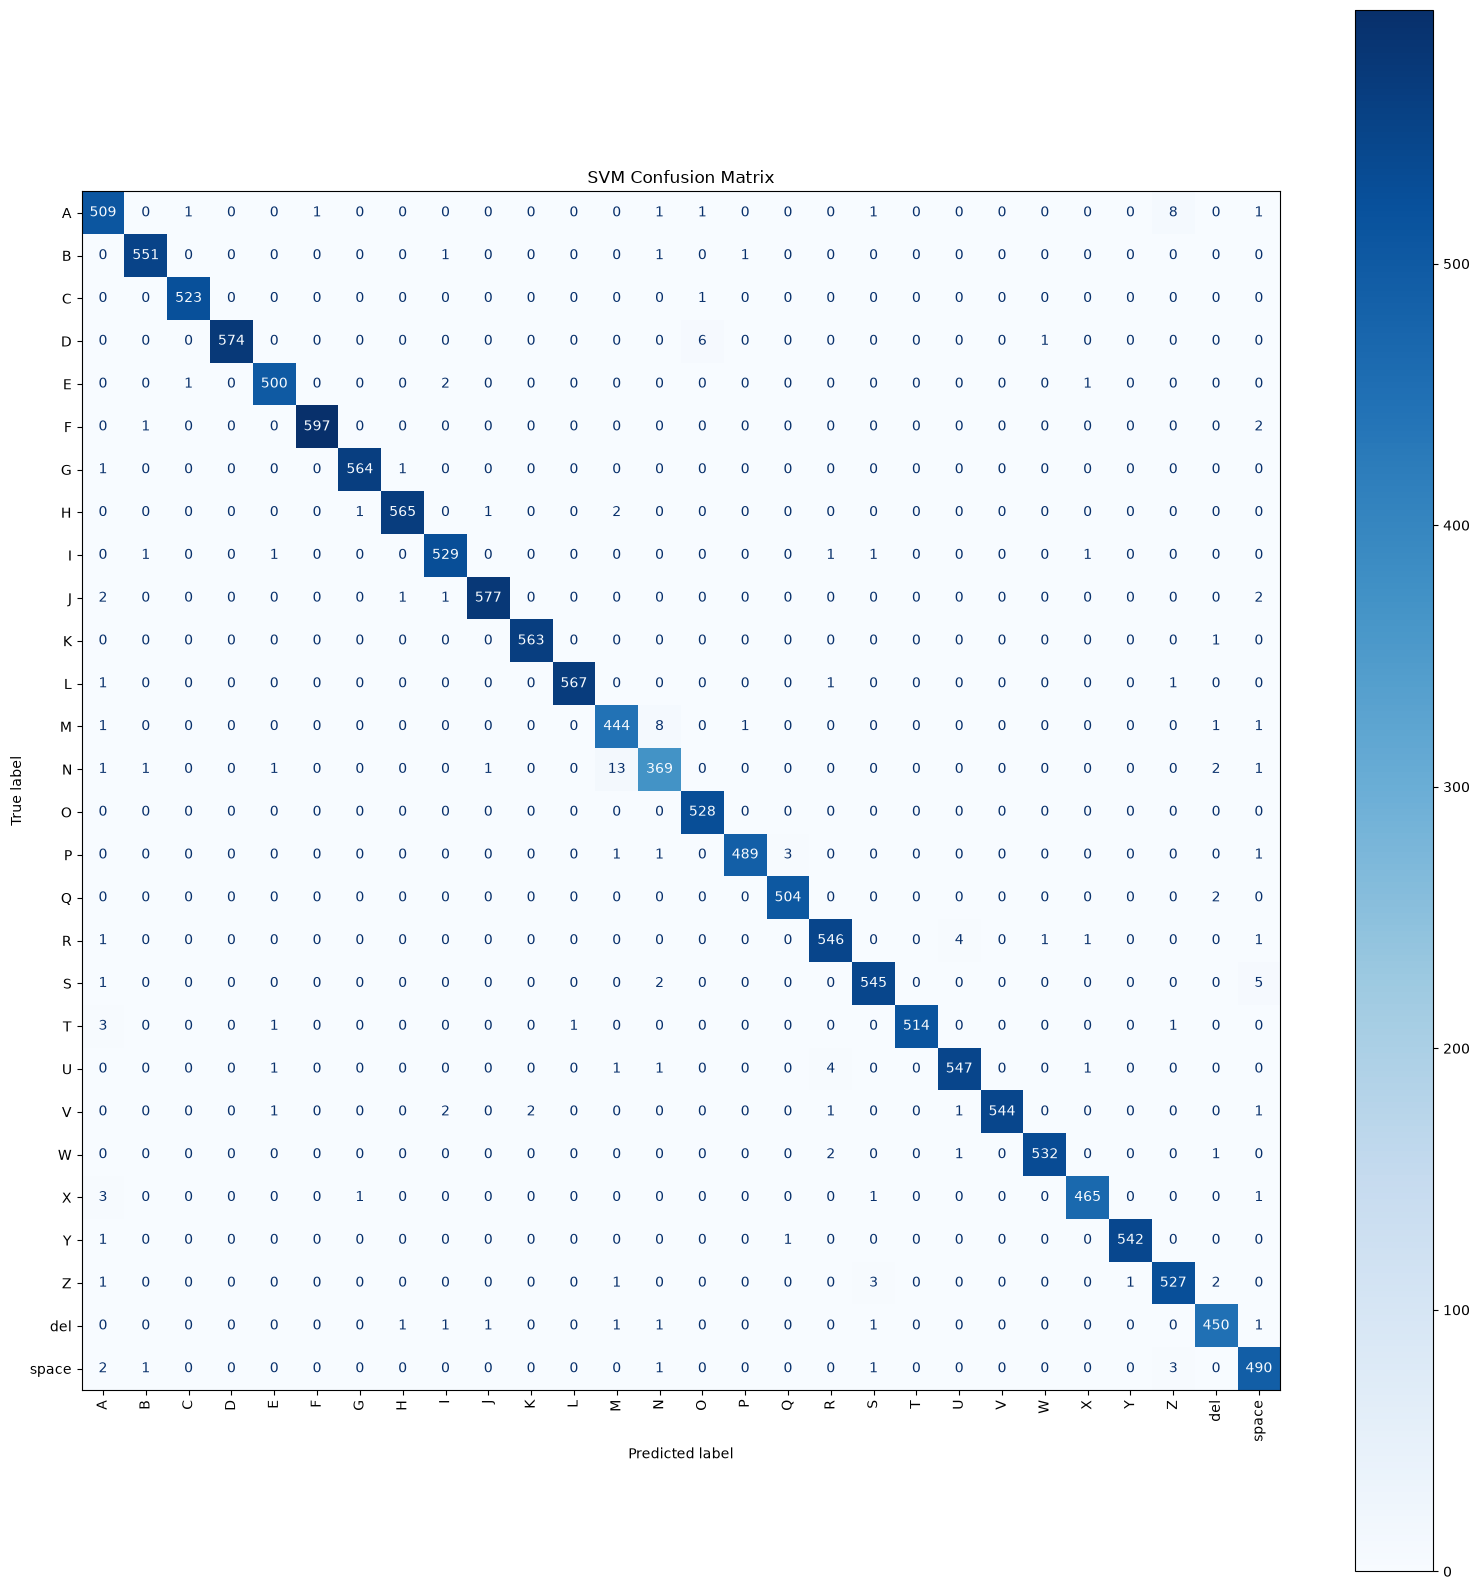

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(16, 16))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    xticks_rotation=90,
    ax=ax
)

plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

In [49]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred_svm)

mistakes = []

for actual in range(len(cm)):
    for predicted in range(len(cm)):

        if actual != predicted and cm[actual, predicted] > 0:

            mistakes.append(
                (
                    cm[actual, predicted],
                    label_encoder.classes_[actual],
                    label_encoder.classes_[predicted]
                )
            )

mistakes.sort(reverse=True)

print("TOP 15 SVM CONFUSIONS")
print("=" * 45)

for count, actual, predicted in mistakes[:15]:
    print(
        f"{actual:>6} → {predicted:<6} : "
        f"{count} samples"
    )

TOP 15 SVM CONFUSIONS
     N → M      : 13 samples
     M → N      : 8 samples
     A → Z      : 8 samples
     D → O      : 6 samples
     S → space  : 5 samples
     U → R      : 4 samples
     R → U      : 4 samples
 space → Z      : 3 samples
     Z → S      : 3 samples
     X → A      : 3 samples
     T → A      : 3 samples
     P → Q      : 3 samples
 space → A      : 2 samples
     Z → del    : 2 samples
     W → R      : 2 samples


In [50]:
correct = np.sum(y_test == y_pred_svm)
wrong = np.sum(y_test != y_pred_svm)

print("Total test samples :", len(y_test))
print("Correct predictions:", correct)
print("Wrong predictions  :", wrong)

print(f"\nAccuracy: {correct / len(y_test) * 100:.2f}%")

Total test samples : 14821
Correct predictions: 14655
Wrong predictions  : 166

Accuracy: 98.88%


##

In [51]:
from pathlib import Path

MODEL_DIR = BASE_PATH / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Model directory:", MODEL_DIR.resolve())

Model directory: D:\Code FIles\VS code files\Project\sign-language-translator\models


In [52]:
import joblib

svm_path = MODEL_DIR / "svm_model.pkl"

joblib.dump(svm_model, svm_path)

print("SVM saved to:")
print(svm_path.resolve())

SVM saved to:
D:\Code FIles\VS code files\Project\sign-language-translator\models\svm_model.pkl


In [53]:
scaler_path = MODEL_DIR / "scaler.pkl"

joblib.dump(scaler, scaler_path)

print("Scaler saved to:")
print(scaler_path.resolve())


Scaler saved to:
D:\Code FIles\VS code files\Project\sign-language-translator\models\scaler.pkl


In [54]:
encoder_path = MODEL_DIR / "label_encoder.pkl"

joblib.dump(label_encoder, encoder_path)

print("Label encoder saved to:")
print(encoder_path.resolve())

Label encoder saved to:
D:\Code FIles\VS code files\Project\sign-language-translator\models\label_encoder.pkl


In [55]:
print("SVM exists    :", svm_path.exists())
print("Scaler exists :", scaler_path.exists())
print("Encoder exists:", encoder_path.exists())

SVM exists    : True
Scaler exists : True
Encoder exists: True


In [56]:
loaded_model = joblib.load(svm_path)
loaded_scaler = joblib.load(scaler_path)
loaded_encoder = joblib.load(encoder_path)

print("All files loaded successfully!")

All files loaded successfully!


In [57]:
sample = X_test.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample)

prediction_encoded = loaded_model.predict(sample_scaled)

prediction = loaded_encoder.inverse_transform(prediction_encoded)

actual = loaded_encoder.inverse_transform(
    np.array([y_test[0]])
)

print("Predicted:", prediction[0])
print("Actual   :", actual[0])

Predicted: X
Actual   : X
